# Random Forest

En este laboratorio vamos a utilizar Radnom Forest para predecir los precios de inmuebles utilizando el dataset de California Housing

### SETUP

Como siempre, instalamos e importamos las librerias y descargamos el dataset 

In [2]:
!pip install -q pandas
!pip install -q numpy==2.2.0
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3

In [10]:
#Importamos librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Descargamos dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UZPRFNucrENAFm25csq6eQ/California-housing.csv")


## Estudio y procesamiento del dataset

Veamos un poco el esquema de nuestro dataset

In [7]:
print(f"--------TIPOS----------- \n {df.dtypes}")

--------TIPOS----------- 
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Target        float64
dtype: object


Vemos que todos los campos son numericos y que tneemos nuestra variable objetivo, convenientemente llamada `Target`. <br>
Separemos entonces nuestro dataset en features y target y armemos los grupos de entrenamiento/validación 

In [8]:
# Separamos en feature/objetivo
X = df.drop(columns=["Target"])
y = df["Target"]

# Armamos set de entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelo

Una vez armados nuestros sets podemos inicializar el modelo, ajustandolo con nuestro set de entrenamiento

In [9]:
# Armamos modelo
n_estimators=100
rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42)

# Ajustamos modelo con set de entrenamiento
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Ahora podemos predecir con nuestro set de testeo y calcular métricas de evaluación

In [11]:
# Predecimos 
y_prediction = rf.predict(X_test)

# Calculamos metricas MSE, MAE y R^2

mse = mean_squared_error(y_test, y_prediction)

mae = mean_absolute_error(y_test, y_prediction)

r2 = r2_score(y_test,y_prediction)

print(f"------------RESULTADOS------------ \n MSE: {mse} \n MAE: {mae} \n R2: {r2}")

------------RESULTADOS------------ 
 MSE: 0.255553781221915 
 MAE: 0.32761335695251953 
 R2: 0.804981661858749


Ahora también estaría bueno poder visualizar más gráficamente los resultados obtenidos, podemos entonces plotear la desviación estándar 

Text(0, 0.5, 'Valores Predecidos')

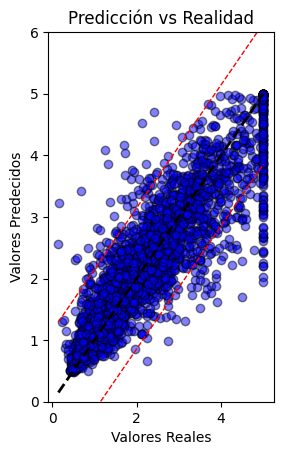

In [ ]:
y_std = np.std(y_test)

plt.figure()

# Ploteo de desviación estandar
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_prediction, alpha=0.5, color="blue",ec='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2,label="perfect model")
plt.plot([y_test.min(), y_test.max()], [y_test.min() + y_std, y_test.max() + y_std], 'r--', lw=1, label="+/-1 Std Dev")
plt.plot([y_test.min(), y_test.max()], [y_test.min() - y_std, y_test.max() - y_std], 'r--', lw=1, )
plt.ylim(0,6)
plt.title("Predicción vs Realidad")
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predecidos")
